In [1]:
# Import required modules

import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.ticker as ticker
from fractions import Fraction
import random
import collections

#

In [2]:
# Common Functions

def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self

def recursive_pop(n_periods, death_chance, pop):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = []
    for i in range(0,n_periods):
        pop = pop*(1-death_chance)+1
        p_function.append(pop)
    return p_function


In [3]:
# Old Version

class environment_o():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history =[]

    def __call__(self):
        # print(self.population)
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population.append(entity())
        self.history.append(len(self.population))

In [4]:
# New Version

class environment_n():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history = []
        self.mortuary = collections.Counter()

    def __call__(self):

        survive, expire = [], []
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
        
        self.population = survive
        self.population.append(entity())
        self.mortuary.update(expire)
        self.history.append(len(self.population))

In [5]:
# Plot

def run_sim(birth_rate, death_chance, n_periods, r_runs, env_sim):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run numerical model (simulation simplified by recursive function) 
    p_function = recursive_pop(n_periods, death_chance, 0)

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        # print(f"\nRun {r}")
        env = env_sim(birth_rate, death_chance)
        for period in range(0, n_periods):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])
        ax.plot(range(0, n_periods), p_function, color='k')


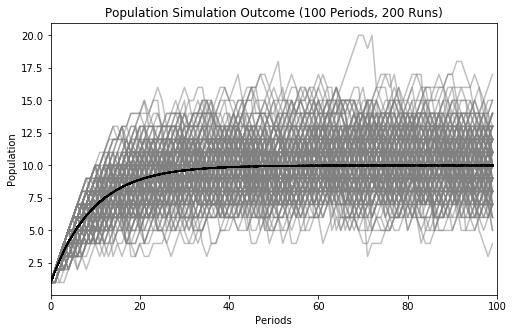

In [6]:
# Run the old simulation
random.seed(10)
run_sim(1, .1, 100, 200, environment_o)

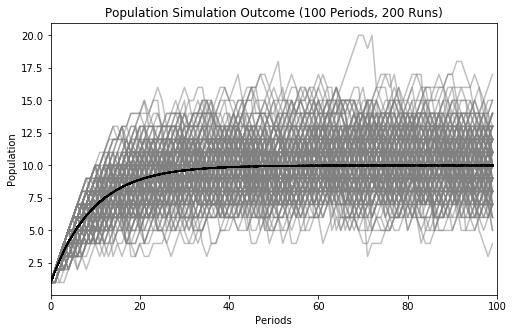

In [7]:
# Run the new simulation
random.seed(10)
run_sim(1, .1, 100, 200, environment_n)